In [1]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)

import random
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
from matplotlib.backends.backend_pdf import PdfPages
import textwrap

import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

import pickle

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/home2/s223695/.local/lib/python3.12/site-packages', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
numpy 1.26.4
pandas 2.2.1
scipy 1.15.3
matplotlib 3.8.3


### Load pySpade data

In [2]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [3]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [4]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

In [5]:
global_df["Pert_name"] = global_df["region"].apply(lambda x: annot_dict[x])
print(global_df.columns)

global_df.head()

Index(['Unnamed: 0', 'idx', 'gene_names', 'chromosome', 'pos', 'strand',
       'color_idx', 'chr_idx', 'region', 'num_cell', 'bin',
       'log(pval)-hypergeom', 'fc', 'Significance_score',
       'fc_by_rand_dist_cpm', 'pval-empirical', 'cpm_perturb', 'cpm_bg',
       'Pert_name'],
      dtype='object')


,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684,NCOA1
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529,NCOA1
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946,NCOA1
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569,NCOA1
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102,NCOA1


### Load TimeCourse data

In [6]:
base_folder_time_course="/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241210_WTC11_lenti_TFtimecourse_NCbg"
csv_path_time_course = {"D4": "D4/Manhattan_plots/filtered_df.csv",
                        "D8": "D8/Manhattan_plots/filtered_df.csv",
                        "D12": "D12/Manhattan_plots/filtered_df.csv",
                        "D29": "D29/Manhattan_plots/filtered_df.csv"
                       }

In [7]:
global_df_time_course_dict = {}
for key, path in csv_path_time_course.items():
    time_course_reg_df_tmp = pd.read_csv(os.path.join(base_folder_time_course,path))
    time_course_reg_df_tmp["Pert_name"] = time_course_reg_df_tmp["region"].apply(lambda x: annot_dict[x])
    global_df_time_course_dict[key] = time_course_reg_df_tmp
    

In [8]:
global_df_time_course_dict["D29"].head()

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,948,8207,SESTD1,chr2,428221212,-,1,1,chr11:5301689-5301949,115,100,-7.604214,0.201813,-6.673719,0.197659,0.0,7.522571,38.098839,OR51B4
1,1009,8704,FN1,chr2,464392594,-,1,1,chr11:5301689-5301949,115,100,-8.174263,0.181507,-7.427298,0.158767,0.0,24.825303,156.416278,OR51B4
2,2802,25076,SDC2,chr8,1487843627,+,1,7,chr11:5301689-5301949,115,100,-10.033726,0.237527,-8.797675,0.227411,0.0,9.013117,39.667541,OR51B4
3,5094,45705,RAB34,chr17,2519498991,-,0,16,chr11:5301689-5301949,115,100,-7.842045,0.316129,-7.064799,0.311457,0.0,16.005367,51.410833,OR51B4
4,5656,50382,RBM42,chr19,2690040318,+,0,18,chr11:5301689-5301949,115,100,-7.848555,0.287628,-7.017792,0.278339,0.0,11.435187,41.109615,OR51B4


### Load Gene Program regulation table

In [9]:
Pert_gp_path = '/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/compare_score_pert_all_k_all_targets_clear_gRNA_12_3_24.pkl'

with open(Pert_gp_path, 'rb') as file:
    compare_score_pert_all_ks = pickle.load(file)

In [10]:
gp_go_path = '/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/TF_full_GO_all_enriched_results.pkl'
with open(gp_go_path, 'rb') as file:
    enrichment_results = pickle.load(file)

In [11]:
top300_gene_path = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_cNMF_figure_2_plots/top_300_genes_K_250_per_program_TF_full.csv"
top300_gene_df = pd.read_csv(top300_gene_path)

In [12]:
!cp {top300_gene_path} ./output_data/top_300_genes_K_250_per_program_TF_full.csv

In [13]:
top300_gene_df.head()

,1,2,3,4,5,6,7,8,9,10,...,241,242,243,244,245,246,247,248,249,250
0,FBN2,CACNA1D,NCCRP1,MT-CO3,SFRP1,GRIK1,ZNF385D,COL1A2,LMO2,H3F3B,...,AL031767.1,PHGR1,LY86,AC018730.1,AC113615.1,TRIM43B,SPDYC,AL035412.1,LINC00583,DDC
1,LAMA2,RSPO3,ZNF385B,MT-CO2,RAB3C,CKB,PRR16,ITGA8,DPP10,GADD45G,...,AL355337.1,AC103702.2,AC051619.8,C2CD4A,HID1-AS1,TRIM49,LINC02715,AC093824.2,KRT86,CTSE
2,MYL3,LBH,TBX18,MT-ATP8,PDE3A,MFGE8,FABP5,COL1A1,CADM1,PHLDA1,...,LINC02061,MATN4,AC009396.3,AC072061.1,RTBDN,MBD3L2,C5orf58,AC120498.4,PTPN7,AC006441.4
3,KCNQ5,EPHA7,TMEM98,MT-CO1,UNC5C,FST,DLGAP1,COL3A1,C7,JUN,...,FAM107A,AC026310.2,PTGDS,AC016888.1,AL596442.4,LEUTX,AL133551.1,AC016229.2,AL606923.2,GJB1
4,LAMA4,SLIT2,KCNMA1,MT-ND4L,AC022784.1,BMP4,PTCHD1-AS,GPC3,AC092691.1,CDKN1C,...,RASSF6,AC069214.1,HOXA2,LINC02071,DNER,TAF11L12,MCMDC2,AC099521.3,HMSD,DLL4


In [14]:
gp_regulation_df = compare_score_pert_all_ks["usage_norm_k_250"]
print(gp_regulation_df.columns)

gp_go_df = enrichment_results[250]
print(gp_go_df.columns)

Index(['Gene', 'Score Column', 'Statistic', 'p-value', 'Log2 Fold Change',
       'Corrected p-value (BH)'],
      dtype='object')
Index(['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value',
       'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score',
       'Genes', 'Source'],
      dtype='object')


### GP FDR detection analysis

In [15]:
gp_regulation_df.head()

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH)
0,non-targeting (self),Usage_1,879230178.0,1.000000,NaN,1.000000
1,ADNP2-P1P2,Usage_1,11343150.5,0.221842,-0.060234,0.788741
2,AEBP1-P1P2,Usage_1,6742183.0,0.096836,0.136552,0.655981
3,AFF1-P1P2,Usage_1,24259033.5,0.999584,0.006465,1.000000
4,AFF2-P1P2,Usage_1,17320479.5,0.720667,0.026586,0.961013


In [16]:
all_pert_list_gp = gp_regulation_df["Gene"].unique()
OR_pert_list_gp = [gene_name for gene_name in all_pert_list_gp if gene_name.startswith("OR")]

In [17]:
FDR_cutoff_list = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

for FDR_cutoff_gp in FDR_cutoff_list:
    gp_regulation_df_sig = gp_regulation_df[gp_regulation_df["Corrected p-value (BH)"]<FDR_cutoff_gp]
    gp_regulation_df_or = gp_regulation_df_sig[gp_regulation_df_sig["Gene"].apply(lambda x: x in OR_pert_list_gp)]
    
    sig_gp_reg_all_num = gp_regulation_df_sig.shape[0]
    sig_gp_reg_of_num = gp_regulation_df_or.shape[0]
    percent_or_reg = sig_gp_reg_of_num/sig_gp_reg_all_num*100
    sig_gp_unq = len(gp_regulation_df_sig["Score Column"].unique())
    
    
    print(f"Thresfold: {FDR_cutoff_gp}")
    print(f"\t Num of GP reg: {sig_gp_reg_all_num}")
    print(f"\t Num of GP reg with OR gene perturb: {sig_gp_reg_of_num}")
    print(f"\t Percent of OR pert regulationm: {percent_or_reg:.2f}")
    print(f"\t Num of GP regulated: {sig_gp_unq}")
    

Thresfold: 0.1
	 Num of GP reg: 6682
	 Num of GP reg with OR gene perturb: 75
	 Percent of OR pert regulationm: 1.12
	 Num of GP regulated: 250
Thresfold: 0.05
	 Num of GP reg: 4627
	 Num of GP reg with OR gene perturb: 37
	 Percent of OR pert regulationm: 0.80
	 Num of GP regulated: 250
Thresfold: 0.01
	 Num of GP reg: 2743
	 Num of GP reg with OR gene perturb: 6
	 Percent of OR pert regulationm: 0.22
	 Num of GP regulated: 247
Thresfold: 0.005
	 Num of GP reg: 2302
	 Num of GP reg with OR gene perturb: 6
	 Percent of OR pert regulationm: 0.26
	 Num of GP regulated: 243
Thresfold: 0.001
	 Num of GP reg: 1681
	 Num of GP reg with OR gene perturb: 1
	 Percent of OR pert regulationm: 0.06
	 Num of GP regulated: 232
Thresfold: 0.0005
	 Num of GP reg: 1527
	 Num of GP reg with OR gene perturb: 0
	 Percent of OR pert regulationm: 0.00
	 Num of GP regulated: 227
Thresfold: 0.0001
	 Num of GP reg: 1207
	 Num of GP reg with OR gene perturb: 0
	 Percent of OR pert regulationm: 0.00
	 Num of GP 

In [18]:
FDR_cutoff_gp = 0.001
gp_regulation_df_sig = gp_regulation_df[gp_regulation_df["Corrected p-value (BH)"]<FDR_cutoff_gp].copy()

In [19]:
FDR_cutoff_go = 0.05
gp_go_df_sig = gp_go_df[gp_go_df["Adjusted P-value"]<FDR_cutoff_go].copy()

In [20]:
gp_regulation_df_sig_target = \
    gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]=="Usage_1"].sort_values("Corrected p-value (BH)")

gp_regulation_df_sig_target_down = \
    gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
gp_regulation_df_sig_target_up = \
    gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]

In [21]:
global_df

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684,NCOA1
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529,NCOA1
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946,NCOA1
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569,NCOA1
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102,NCOA1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27573,31558319,38228,FITM1,chr14,2215538585,+,1,13,chrX:49042845-49043845,794,750,-12.332692,1.287023,-13.735282,1.285053,0.0,135.824176,105.693160,TFE3
27574,31559427,47101,PECAM1,chr17,2555194338,-,0,16,chrX:49042845-49043845,794,750,-9.699542,16.178142,-11.238323,14.979639,0.0,3.247754,0.207479,TFE3
27575,31579300,28022,DPP7,chr9,1673604089,-,0,8,chr19:52527153-52528153,811,750,-19.835936,0.714110,-19.482662,0.715293,0.0,186.828915,261.196259,ZNF808
27576,31582291,51353,ZNF808,chr19,2706938940,+,0,18,chr19:52527153-52528153,811,750,-18.799928,0.471482,-18.062261,0.474419,0.0,17.071369,35.994817,ZNF808


In [22]:
DEG_tf_regulation = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                              (global_df["gene_names"].apply(lambda x: x in target_down_tf_name))
                             ]

In [23]:
gp_name_list = gp_regulation_df["Score Column"].unique()

### Load Graph node position from previous analysis

In [24]:
with open("./output_data/gp_graph_pos.pickle","rb") as f:
    pos_dict = pickle.load(f)

### GP regulating graph analysis

In [25]:
def generate_graph(TF_regulation_df, tf_name_list):
    # 2) Create a directed graph
    G = nx.DiGraph()

    # Add TF nodes to the graph
    G.add_nodes_from(tf_name_list)
    
    #Get expression level of the TFs
    tf_exp_series = \
        global_df[global_df["gene_names"].apply(lambda x: x in tf_name_list)].groupby("gene_names")["cpm_bg"].mean()
    
    # 3) Add edges
    # Edge direction: regulating_tf -> tf_name
    for row in TF_regulation_df.itertuples():
        # Remove self-loops
        if row.gene_names == row.Pert_name:
            continue

        # Add directed edges with attributes
        # We store log2FC for weight/width and -log10(p-value) for opacity
        log_fc = np.log2(row.fc)
        
        # Calculate negative log p-value (add small epsilon to avoid log(0))
        # Using pval_empirical based on your data structure
        nlog_p = -row.Significance_score
        
        G.add_edge(row.Pert_name, row.gene_names, weight=log_fc, significance=nlog_p)
    return G, tf_exp_series

In [26]:
graph_gp_dict = {}
tf_exp_sr_dict = {}

#Additional dict for total graph
graph_gp_total_dict = {}
tf_exp_sr_total_dict = {}
graph_gp_time_course_total_dict = {}

net_info_df = pd.DataFrame(columns=["Num_nodes","Num_edges","Density",
                                    "Max_indegree_node","Max_indegree_centrality","all_centrality"])

net_info_time_course_df = pd.DataFrame(columns=["Num_nodes","Num_edges","Density",
                                    "Max_indegree_node","Max_indegree_centrality","all_centrality"])

print("Generating graphs...")
for target_gene in tqdm(gp_name_list):
    gp_id = target_gene.split("_")[1]

    # Filter data (Same logic as your original code)
    gp_regulation_df_sig_target = \
        gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]==target_gene].sort_values("Corrected p-value (BH)")

    gp_regulation_df_sig_target_down = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
    gp_regulation_df_sig_target_up = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

    target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]
    target_up_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_up["Gene"].values]
    taget_total_tf_name = np.unique(np.concatenate([target_down_tf_name, target_up_tf_name]))
    
    DEG_tf_regulation_down  = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in target_down_tf_name))]
    DEG_tf_regulation_up    = global_df[(global_df["Pert_name"].apply(lambda x: x in target_up_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in target_up_tf_name))]
    DEG_tf_regulation_total = global_df[(global_df["Pert_name"].apply(lambda x: x in taget_total_tf_name)) & \
                                        (global_df["gene_names"].apply(lambda x: x in taget_total_tf_name))]
    
    #Graph of time-course data
    Graph_time_course_regulation_dict = {}
    for key,time_point_df in global_df_time_course_dict.items():
        DEG_tf_regulation_time_total = time_point_df[(time_point_df["Pert_name"].apply(lambda x: x in taget_total_tf_name)) & \
                                                     (time_point_df["gene_names"].apply(lambda x: x in taget_total_tf_name))]
        G_total_time_course, tf_exp_total_time_course = \
                generate_graph(DEG_tf_regulation_time_total, taget_total_tf_name)
        
        #Assign Up/Down-regulation of target gp for later visualization
        for node_name in G_total_time_course.nodes():
            if node_name in target_down_tf_name:
                G_total_time_course.nodes()[node_name]["type"] = "down"
            elif node_name in target_up_tf_name:
                G_total_time_course.nodes()[node_name]["type"] = "up"
            
        Graph_time_course_regulation_dict[key] = G_total_time_course
    
    # Use the MODIFIED function
    G_up, tf_exp_up = generate_graph(DEG_tf_regulation_up, target_up_tf_name)
    G_down, tf_exp_down = generate_graph(DEG_tf_regulation_down, target_down_tf_name)
    G_total, tf_exp_total = generate_graph(DEG_tf_regulation_total, taget_total_tf_name)
    
    #Assign Up/Down-regulation of target gp for later visualization
    for node_name in G_total.nodes():
        if node_name in target_down_tf_name:
            G_total.nodes()[node_name]["type"] = "down"
        elif node_name in target_up_tf_name:
            G_total.nodes()[node_name]["type"] = "up"
        
    # Calculate stats (simplified for brevity, keeping your structure)
    density_up = nx.density(G_up)
    density_down = nx.density(G_down)
    density_total = nx.density(G_total)
    
    # Helper for centrality
    def get_max_centrality(G):
        if len(G) == 0: return None, None, None
        cent = nx.in_degree_centrality(G)
        if not cent: return None, None, None
        max_n = max(cent, key=cent.get)
        return max_n, cent[max_n], cent

    max_node_up, max_value_up, cent_dict_up = get_max_centrality(G_up)
    max_node_down, max_value_down, cent_dict_down = get_max_centrality(G_down)
    max_node_total, max_value_total, cent_dict_total = get_max_centrality(G_total)

    net_info_df.loc[target_gene+"_up"] = [G_up.number_of_nodes(), G_up.number_of_edges(),
                                          density_up, max_node_up, max_value_up, cent_dict_up]
    net_info_df.loc[target_gene+"_down"] = [G_down.number_of_nodes(), G_down.number_of_edges(),
                                          density_down, max_node_down, max_value_down, cent_dict_down]
    net_info_df.loc[target_gene+"_total"] = [G_total.number_of_nodes(), G_total.number_of_edges(),
                                             density_total, max_node_total, max_value_total, cent_dict_total]
    
    for key_day, G_tmp in Graph_time_course_regulation_dict.items():
            density_tmp_time = nx.density(G_tmp)
            max_node_tmp, max_value_tmp, cent_dict_tmp = get_max_centrality(G_tmp)
            
            net_info_time_course_df.loc[f"{target_gene}_{key_day}_total"] = \
                                            [G_tmp.number_of_nodes(), G_tmp.number_of_edges(),
                                             density_tmp_time, max_node_tmp, max_value_tmp, cent_dict_tmp]
    graph_gp_dict[target_gene+"_up"] = G_up
    graph_gp_dict[target_gene+"_down"] = G_down
    graph_gp_total_dict[target_gene+"_total"] = G_total
    graph_gp_time_course_total_dict[target_gene+"_total"] = Graph_time_course_regulation_dict
    
    tf_exp_sr_dict[target_gene+"_up"] = tf_exp_up
    tf_exp_sr_dict[target_gene+"_down"] = tf_exp_down
    tf_exp_sr_total_dict[target_gene+"_total"] = tf_exp_total

net_info_df = net_info_df.reset_index(drop=False)

Generating graphs...


100%|██████████| 250/250 [05:43<00:00,  1.38s/it]


In [27]:
graph_gp_total_dict['Usage_1_total'].nodes()

NodeView(('ARID3A', 'ARID3B', 'BNC1', 'BPTF', 'CAMTA2', 'CDX4', 'CHAMP1', 'CREBBP', 'DBX2', 'ELMSAN1', 'ETV3', 'GATA4', 'GLI3', 'HAND2', 'HMG20A', 'HOXB4', 'ID2', 'IKZF1', 'IRF4', 'ISL1', 'KAT7', 'LEF1', 'LZTR1', 'LZTS1', 'MAPK8IP1', 'MBD6', 'MEF2A', 'MEF2C', 'MEF2D', 'MEIS1', 'MLX', 'MTF2', 'MXD3', 'MYOCD', 'MYRF', 'NKX2', 'NOTO', 'OR2T29', 'OVOL1', 'PBX2', 'PCGF2', 'PCGF6', 'PIN1', 'PITX2', 'POU5F1B', 'RCOR2', 'RNF2', 'SMAD5', 'SOX11', 'SOX4', 'SP4', 'SUPT4H1', 'TBX2', 'TBX20', 'TCF7', 'TFAP4', 'THAP4', 'TP53', 'ZBTB10', 'ZNF148', 'ZNF18', 'ZNF20', 'ZNF331', 'ZNF425', 'ZNF436', 'ZNF460', 'ZNF580', 'ZNF649', 'ZNF787', 'ZNF814', 'ZSCAN10'))

In [28]:
net_info_time_course_df["GP_name"] = net_info_time_course_df.index.map(lambda x:"Usage_"+str(x.split("_")[1]))
net_info_time_course_df["timepoint"] = net_info_time_course_df.index.map(lambda x:x.split("_")[2])

In [29]:
net_info_time_course_df.head()

,Num_nodes,Num_edges,Density,Max_indegree_node,Max_indegree_centrality,all_centrality,GP_name,timepoint
Usage_1_D4_total,71.0,65.0,0.013078,HOXB4,0.114286,"{'ARID3A': 0.07142857142857142, 'ARID3B': 0.0,...",Usage_1,D4
Usage_1_D8_total,71.0,140.0,0.028169,HOXB4,0.185714,"{'ARID3A': 0.014285714285714285, 'ARID3B': 0.0...",Usage_1,D8
Usage_1_D12_total,71.0,121.0,0.024346,MYOCD,0.214286,"{'ARID3A': 0.014285714285714285, 'ARID3B': 0.0...",Usage_1,D12
Usage_1_D29_total,71.0,116.0,0.023340,BNC1,0.200000,"{'ARID3A': 0.0, 'ARID3B': 0.0, 'BNC1': 0.19999...",Usage_1,D29
Usage_2_D4_total,17.0,16.0,0.058824,SOX4,0.250000,"{'ARNT': 0.0, 'CHAMP1': 0.0, 'HAND1': 0.0, 'HI...",Usage_2,D4


In [30]:
def create_custom_legend(max_nlp,width_base=0.5,width_scale=1.5):
    """
    Creates and returns a list of handles for the legend.
    """
    handles = []
    
    # --- Color (Direction) ---
    handles.append(mpatches.Patch(color='none', label='[Regulation Type]'))
    handles.append(mlines.Line2D([], [], color='red', marker='>', markersize=10, label='Up-regulation (FC > 1)'))
    handles.append(mlines.Line2D([], [], color='blue', marker='>', markersize=10, label='Down-regulation (FC < 1)'))
    
    # --- Width (Effect Size: |log2FC|) ---
    handles.append(mpatches.Patch(color='none', label='\n[Effect Size (|log2FC|)]'))
    # Display representative values: 1, 3, 5
    for val in [1, 3, 5]:
        width = width_base + val * width_scale
        handles.append(mlines.Line2D([], [], color='gray', linewidth=width, label=f'|log2FC| = {val}'))

    # --- Opacity (Significance: -log10(p-val)) ---
    handles.append(mpatches.Patch(color='none', label='\n[Significance (-log10 Padj)]'))
    
    intervals = [max_nlp*0.25,max_nlp*0.5,max_nlp]
    for val in intervals:
        alpha = 0.2 + 0.8 * (val / max_nlp)
        alpha = min(1.0, max(0.2, alpha))
        # Create RGB+Alpha color for the legend
        c = (0.5, 0.5, 0.5, alpha) 
        handles.append(mlines.Line2D([], [], color=c, linewidth=3, label=f'-log10(P) ≈ {val:.1f}'))

    # --- Node Border (Top 300 Gene) ---
    handles.append(mpatches.Patch(color='none', label='\n[Node Type]'))
    
    # Node with thick border (Dummy for legend)
    # Represented using Line2D marker
    handles.append(mlines.Line2D([], [], color='white', marker='o', markeredgecolor='black', 
                                 markeredgewidth=3.0, markersize=10, label='Included in Top 300 Genes'))
    # Node with normal border
    handles.append(mlines.Line2D([], [], color='white', marker='o', markeredgecolor='black', 
                                 markeredgewidth=1.0, markersize=10, label='Others'))
    
    return handles

In [31]:
#Plot time course data
output_filename = "./Plot/GRN_plot_total_time_course.pdf"
max_nlp = 20
with PdfPages(output_filename) as pdf:
    # The legend objects are fixed, so create them once,
    # but ax.legend() must be called inside the loop to place them on each page
    legend_handles = create_custom_legend(max_nlp)

    for key, graph_dict in tqdm(graph_gp_time_course_total_dict.items()):
        for key_day, G in graph_dict.items():
            if G.number_of_nodes() == 0:
                continue

            gp_id_str = key.split("_")[1] 

            # Retrieve Top 300 list
            if gp_id_str in top300_gene_df.columns:
                top300_list = set(top300_gene_df[gp_id_str].values)
            elif gp_id_str.isdigit() and int(gp_id_str) in top300_gene_df.columns:
                top300_list = set(top300_gene_df[int(gp_id_str)].values)
            else:
                top300_list = set()

            # Layout
            pos = pos_dict[key]

            # Determine edge styles
            edge_colors = []
            edge_widths = []

            for u, v, data in G.edges(data=True):
                weight = data['weight']       # log2FC
                sig = data['significance']    # -log10(p-value)

                # Width: Global scale is implicitly consistent formula-wise
                width = 0.5 + abs(weight) * 1.5
                edge_widths.append(width)

                # Color base
                if weight > 0:
                    base_rgb = (0, 0, 1) # Blue
                else:
                    base_rgb = (1, 0, 0) # Red

                # Opacity: Global Normalization using global_max_nlp
                alpha = 0.2 + 0.8 * (sig / max_nlp)
                alpha = min(1.0, max(0.2, alpha))

                edge_colors.append(base_rgb + (alpha,))

            # Plot
            plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
            ax = plt.gca()

            # Edges
            nx.draw_networkx_edges(
                G,
                pos,
                edge_color=edge_colors,
                width=edge_widths,
                arrows=True,
                arrowsize=20,
                connectionstyle="arc3,rad=0.15",
                min_source_margin=15,
                min_target_margin=15,
            )

            # Nodes
            for node in G.nodes():
                x, y = pos[node]
                is_top300 = node in top300_list

                if is_top300:
                    box_lw = 3.0
                    font_weight = 'bold'
                else:
                    box_lw = 1.0
                    font_weight = 'normal'

                if G.nodes()[node]["type"] =="up":
                    box_color = "blue"
                elif G.nodes()[node]["type"] =="down":
                    box_color = "red"
                else:
                    box_color = "black"

                ax.text(
                    x, y, node,
                    fontsize=9,
                    fontweight=font_weight,
                    horizontalalignment='center',
                    verticalalignment='center',
                    bbox=dict(
                        boxstyle="round,pad=0.35",
                        fc="white",
                        ec=box_color,
                        lw=box_lw,
                        alpha=0.9
                    ),
                    zorder=10
                )

            plt.axis("off")
            plt.margins(0.1)

            # Title
            plt.title(f"TF-TF Regulatory Network around {key_day}:{key}", fontsize=16)

            # Add Legend
            # Place outside the plot (e.g., top right) using bbox_to_anchor
            lgd = ax.legend(handles=legend_handles, loc='upper left', 
                            bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                            title="Legend (Unified Scale)", frameon=True)

            # Save PDF (use bbox_inches='tight' to prevent legend from being cut off)
            pdf.savefig(bbox_inches='tight', bbox_extra_artists=(lgd,))
            plt.close()

print(f"PDF saved to {output_filename}")

  0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_1947092/2731271010.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
100%|██████████| 250/250 [01:23<00:00,  2.99it/s]


PDF saved to ./Plot/GRN_plot_total_time_course.pdf


### MYOCD centric regulation overtime

In [32]:
MYOCD_upstream_genes = [["MYOCD"]]
for key, graph_time in graph_gp_time_course_total_dict['Usage_1_total'].items():
    upstream_node_list = list(graph_time.predecessors("MYOCD"))
    MYOCD_upstream_genes.append(upstream_node_list)

MYOCD_upstream_genes = np.unique(np.concatenate(MYOCD_upstream_genes))

In [33]:
# Use one reference graph for stable node classification
G_ref = graph_gp_time_course_total_dict['Usage_1_total']["D12"].subgraph(MYOCD_upstream_genes).copy()

# Define regulators based on all time points
up_regulator = []
down_regulator = []

for key, G_full in graph_gp_time_course_total_dict['Usage_1_total'].items():
    G_tmp = G_full.subgraph(MYOCD_upstream_genes).copy()

    for u, v, data in G_tmp.in_edges("MYOCD", data=True):
        if data["weight"] < 0:
            up_regulator.append(u)
        elif data["weight"] > 0:
            down_regulator.append(u)

# Remove duplicates while preserving order
up_regulator = list(dict.fromkeys(up_regulator))
down_regulator = list(dict.fromkeys(down_regulator))

print(f"Overlap: {np.intersect1d(up_regulator, down_regulator)}")

# Define other nodes from reference graph
other_nodes = [
    n for n in G_ref.nodes()
    if n != "MYOCD" and n not in up_regulator and n not in down_regulator
]

# Split other nodes into upper/lower/middle groups
upper_others = []
lower_others = []
middle_others = []

up_set = set(up_regulator)
down_set = set(down_regulator)

for node in other_nodes:
    neighbors = set(G_ref.predecessors(node)).union(set(G_ref.successors(node)))

    if neighbors & up_set:
        upper_others.append(node)
    elif neighbors & down_set:
        lower_others.append(node)
    else:
        middle_others.append(node)


def place_two_rows(nodes, y_top, y_bottom, x_span=4.5):
    """
    Place nodes in two rows while preserving the original left-to-right order.

    Example:
    [A, B, C, D, E, F]
    -> top:    A, C, E
    -> bottom: B, D, F

    This keeps the visual column order from left to right.
    """
    pos_part = {}
    n = len(nodes)

    if n == 0:
        return pos_part
    if n == 1:
        pos_part[nodes[0]] = (0.0, y_top)
        return pos_part

    top_nodes = nodes[::2]
    bottom_nodes = nodes[1::2]

    n_cols = max(len(top_nodes), len(bottom_nodes))

    if n_cols == 1:
        xs = np.array([0.0])
    else:
        xs = np.linspace(-x_span, x_span, n_cols)

    for i, node in enumerate(top_nodes):
        pos_part[node] = (float(xs[i]), float(y_top))

    for i, node in enumerate(bottom_nodes):
        pos_part[node] = (float(xs[i]), float(y_bottom))

    return pos_part


def place_horizontal(nodes, y, x_span=5.0):
    """
    Place nodes in one horizontal row.
    """
    pos_part = {}
    n = len(nodes)

    if n == 0:
        return pos_part
    elif n == 1:
        pos_part[nodes[0]] = (0.0, y)
    else:
        xs = np.linspace(-x_span, x_span, n)
        for node, x in zip(nodes, xs):
            pos_part[node] = (float(x), float(y))

    return pos_part


# Build position dictionary
pos_D12 = {}

# Center node
pos_D12["MYOCD"] = (0.0, 0.0)

# Direct regulators in two rows to reduce width
# Up regulators: two rows above MYOCD
pos_D12.update(place_two_rows(up_regulator, y_top=2.8, y_bottom=1.8, x_span=4.2))

# Down regulators: two rows below MYOCD
pos_D12.update(place_two_rows(down_regulator, y_top=-1.8, y_bottom=-2.8, x_span=4.2))

# Other nodes, also slightly compacted
pos_D12.update(place_two_rows(upper_others, y_top=4.6, y_bottom=3.7, x_span=5.2))
pos_D12.update(place_two_rows(lower_others, y_top=-3.7, y_bottom=-4.6, x_span=5.2))

# Middle nodes on the left/right, but more compact
if len(middle_others) > 0:
    ys = np.linspace(-1.2, 1.2, len(middle_others))
    for i, (node, y) in enumerate(zip(middle_others, ys)):
        x = -6.0 if i % 2 == 0 else 6.0
        pos_D12[node] = (x, float(y))

Overlap: []


/tmp/ipykernel_1947092/3379812020.py:56: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


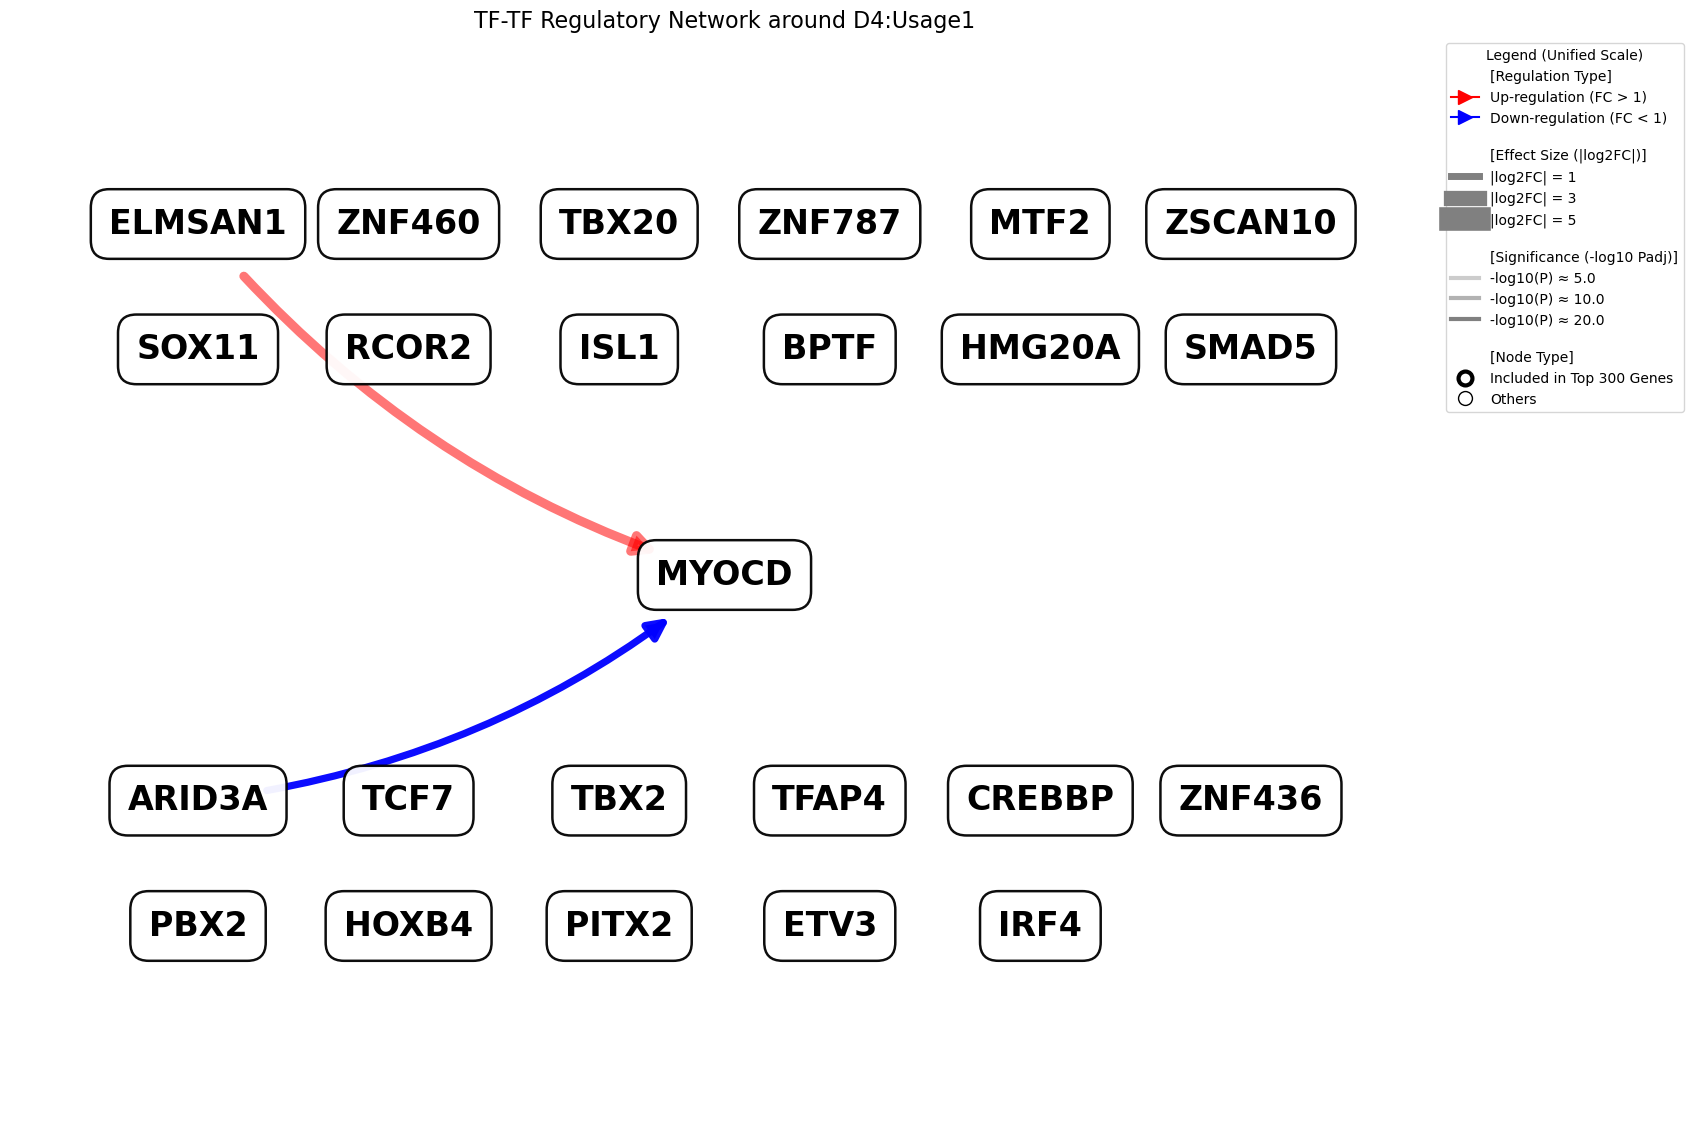

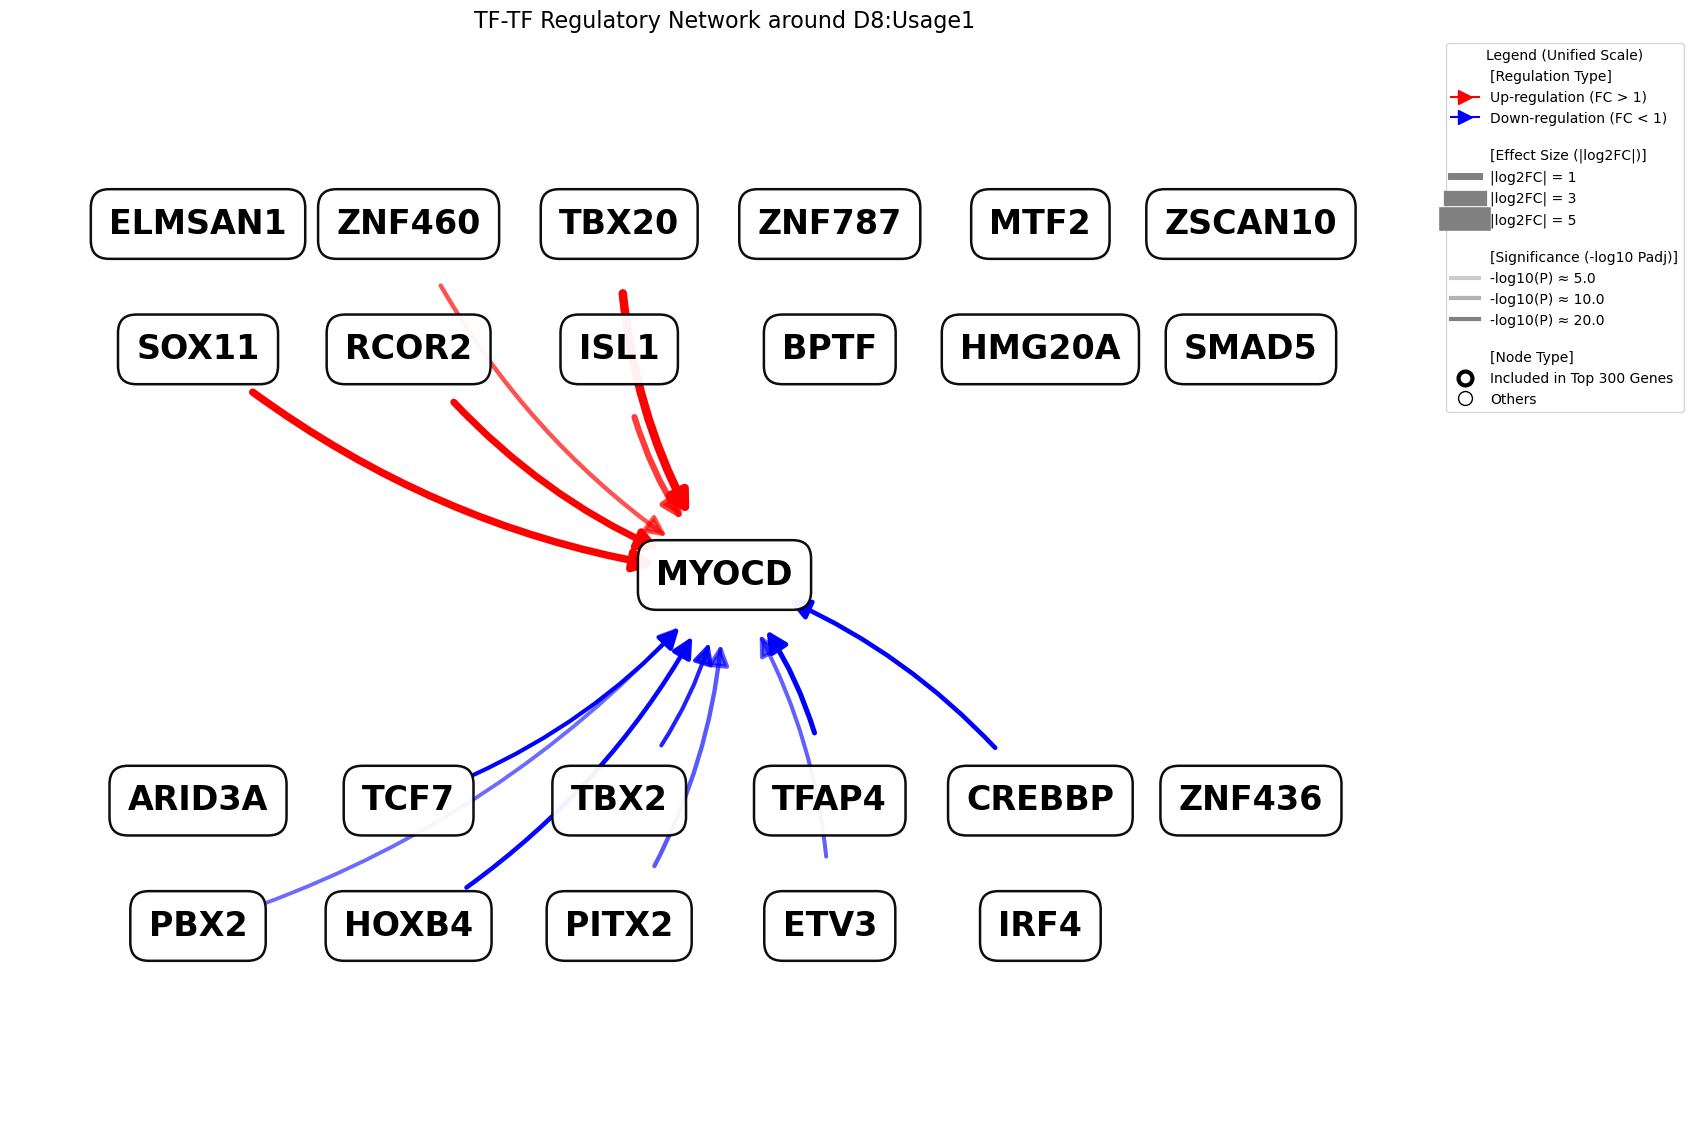

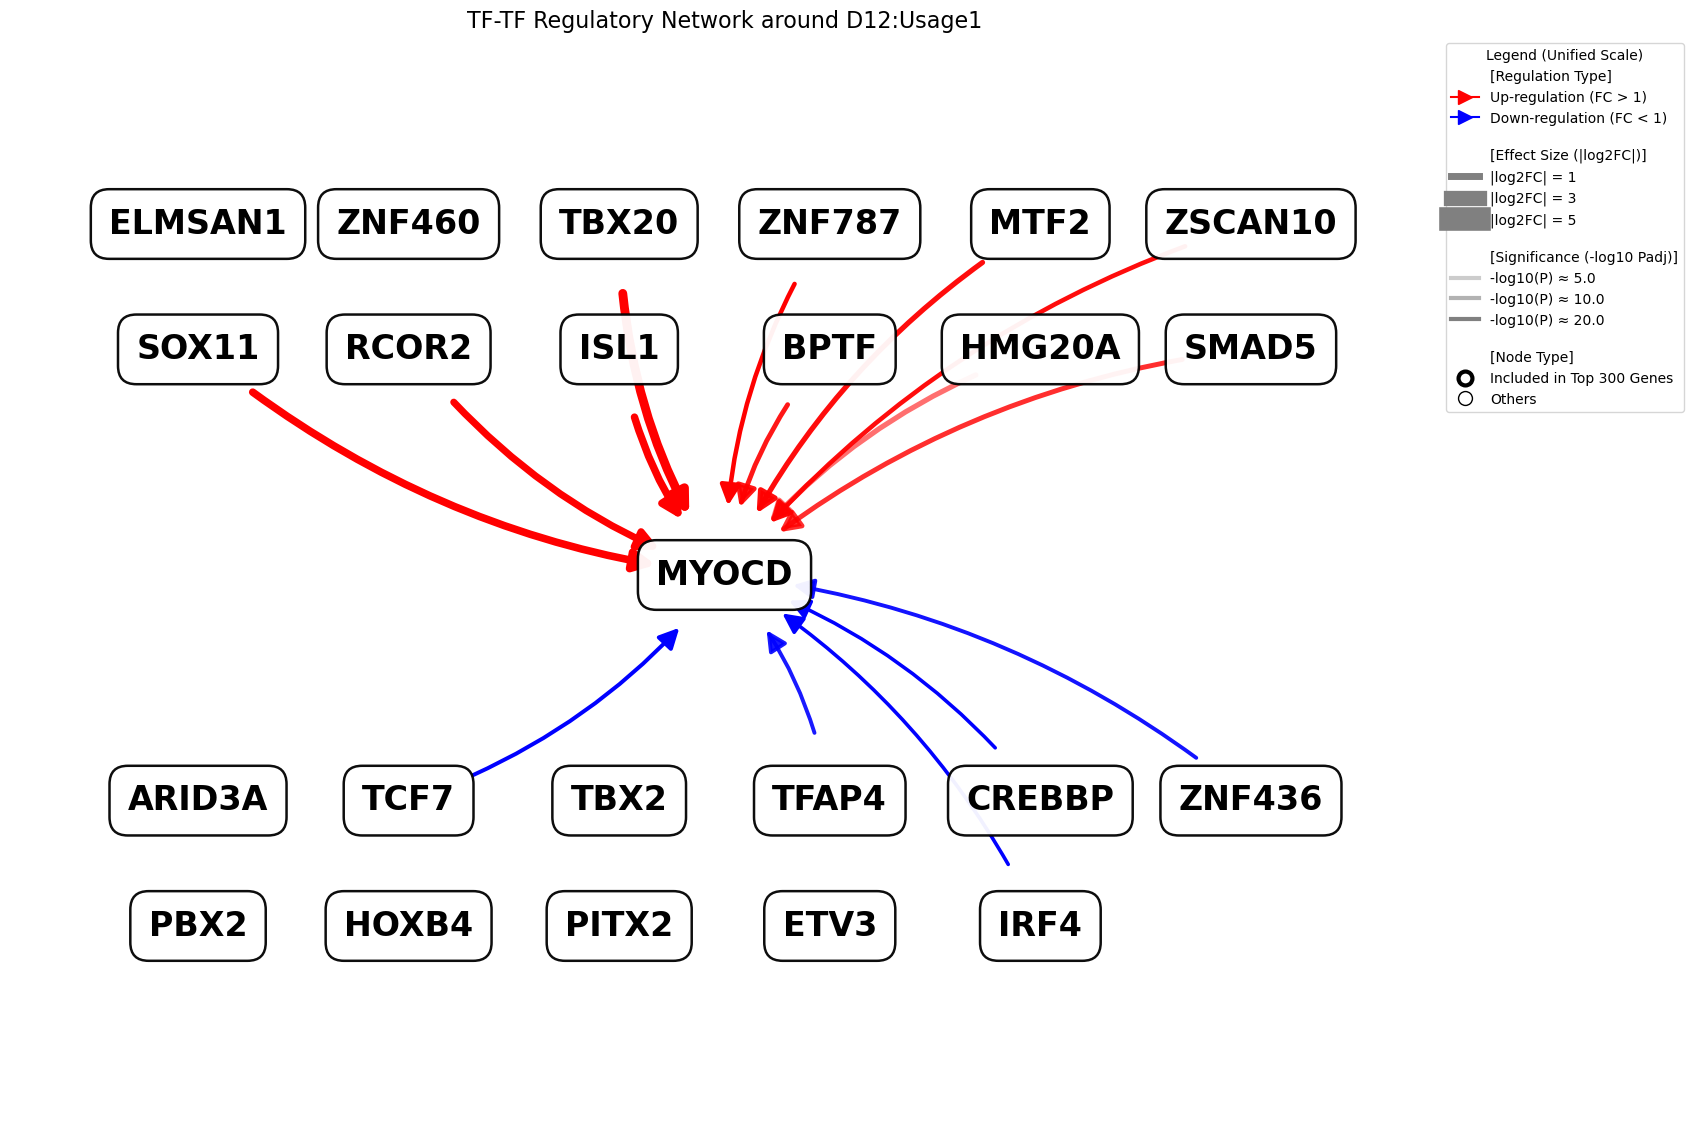

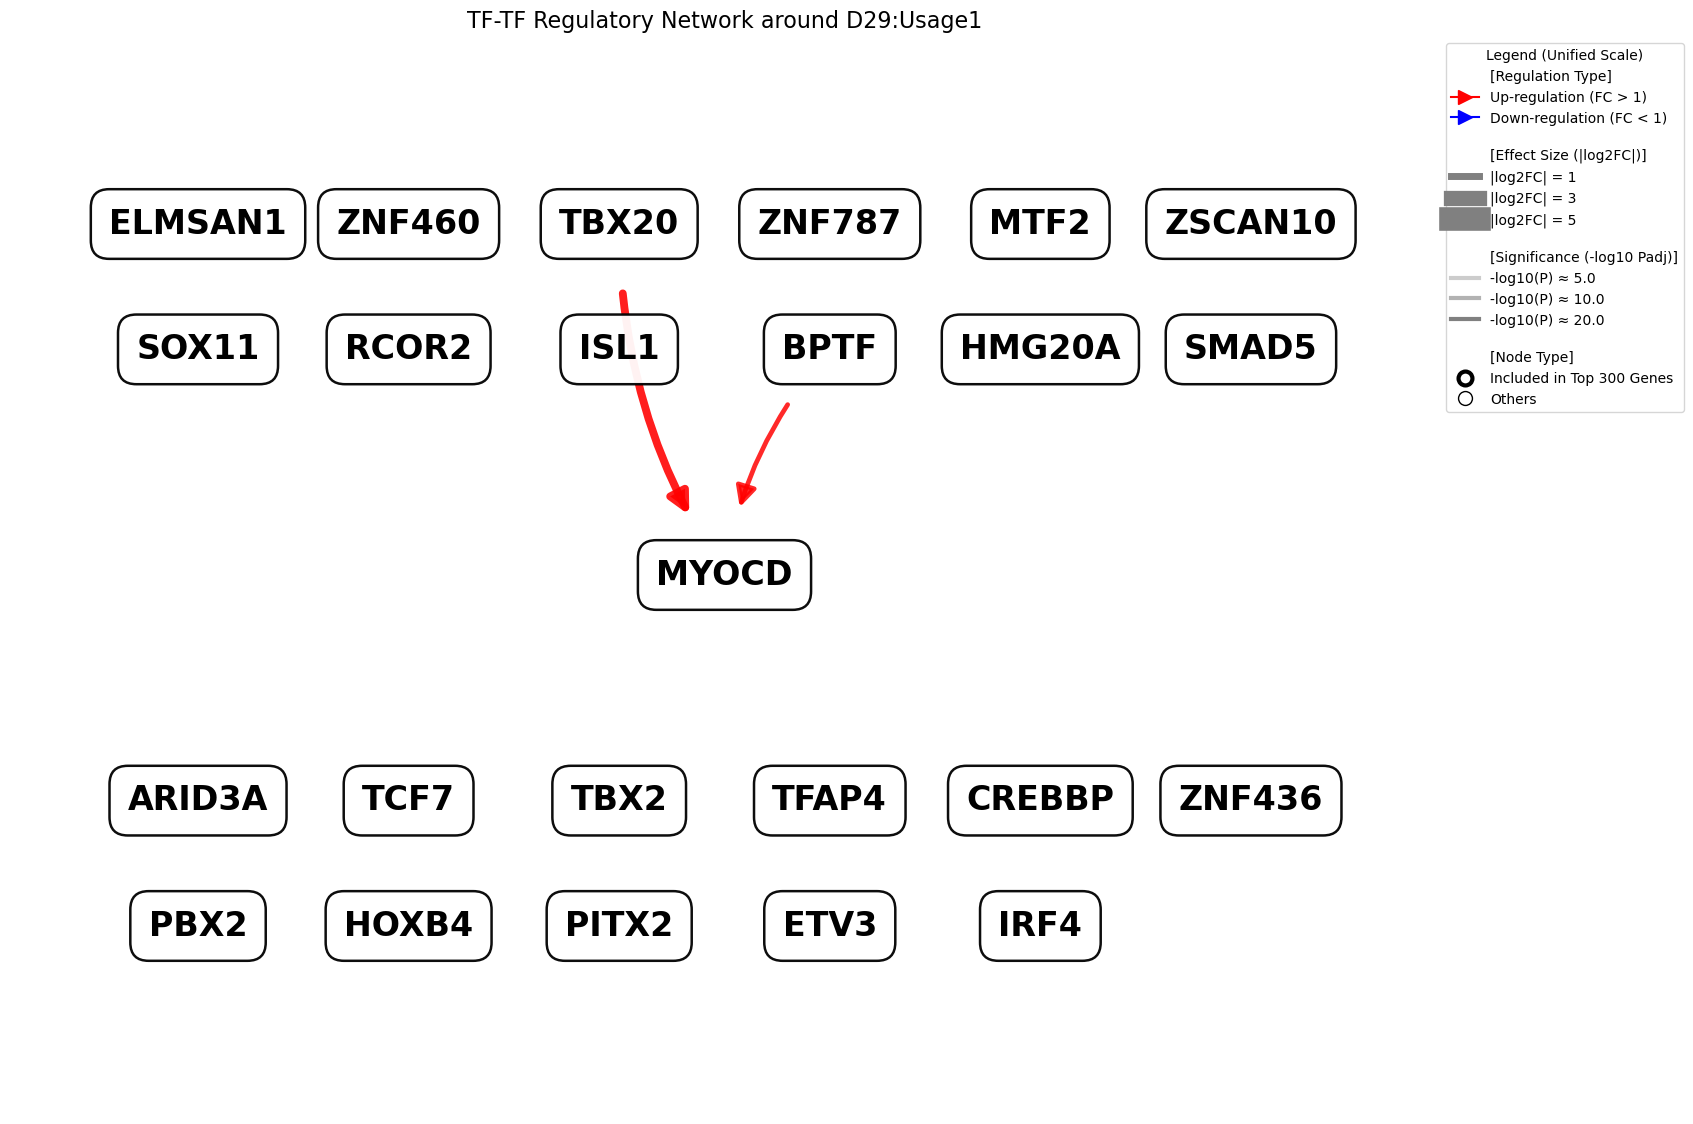

In [34]:
# Fixed layout prepared once
fixed_pos = pos_D12.copy()

# Fixed axis range prepared once
x_vals = [xy[0] for xy in fixed_pos.values()]
y_vals = [xy[1] for xy in fixed_pos.values()]

x_margin = 1.5
y_margin = 1.5

x_min, x_max = min(x_vals) - x_margin, max(x_vals) + x_margin
y_min, y_max = min(y_vals) - y_margin, max(y_vals) + y_margin

output_filename = "./Plot/GRN_MYOCD_GP1_timecourse.pdf"
max_nlp = 20

legend_handles = create_custom_legend(max_nlp,2,3)

with PdfPages(output_filename) as pdf:
    for key, graph_time in graph_gp_time_course_total_dict['Usage_1_total'].items():
        G = graph_time.subgraph(MYOCD_upstream_genes).copy()
    
        # Keep only edges entering MYOCD, but retain all nodes
        edges_to_keep = set(G.in_edges("MYOCD"))
        edges_to_remove = [(u, v) for u, v in G.edges() if (u, v) not in edges_to_keep]
        G.remove_edges_from(edges_to_remove)
    
        # Use fixed layout
        pos = {node: fixed_pos[node] for node in G.nodes() if node in fixed_pos}
    
        # Determine edge styles
        edge_colors = []
        edge_widths = []
    
        for u, v, data in G.edges(data=True):
            weight = data["weight"]
            sig = data["significance"]
    
            width = 2 + abs(weight) * 3
            edge_widths.append(width)
    
            if weight > 0:
                base_rgb = (0, 0, 1)  # Blue
            else:
                base_rgb = (1, 0, 0)  # Red
    
            alpha = 0.2 + 0.8 * (sig / max_nlp)
            alpha = min(1.0, max(0.2, alpha))
    
            edge_colors.append(base_rgb + (alpha,))
    
        # Plot
        fig, ax = plt.subplots(figsize=(20, 14))
    
        # Draw edges
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color=edge_colors,
            width=edge_widths,
            arrows=True,
            arrowsize=30,
            connectionstyle="arc3,rad=0.15",
            min_source_margin=50,
            min_target_margin=50,
        )
    
        # Draw nodes as text boxes
        for node in G.nodes():
            if node not in pos:
                continue
    
            x, y = pos[node]
    
            box_lw = 1.0
            font_weight = "normal"
            box_color = "black"
    
            ax.text(
                x, y, node,
                fontsize=24,
                fontweight="bold",
                horizontalalignment="center",
                verticalalignment="center",
                bbox=dict(
                    boxstyle="round,pad=0.55",
                    fc="white",
                    ec=box_color,
                    lw=1.8,
                    alpha=0.95
                ),
                zorder=10
            )
    
        # Fix axis range so node positions appear identical across plots
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
        ax.set_aspect("equal")
        ax.axis("off")
    
        plt.title(f"TF-TF Regulatory Network around {key}:Usage1", fontsize=16)
    
        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.0, 1.0),
            fontsize=10,
            title="Legend (Unified Scale)",
            frameon=True
        )
    
        #Save
        pdf.savefig(fig)
        plt.show()

In [35]:
MYOCD_upstream_genes

array(['ARID3A', 'BPTF', 'CREBBP', 'ELMSAN1', 'ETV3', 'HMG20A', 'HOXB4',
       'IRF4', 'ISL1', 'MTF2', 'MYOCD', 'PBX2', 'PITX2', 'RCOR2', 'SMAD5',
       'SOX11', 'TBX2', 'TBX20', 'TCF7', 'TFAP4', 'ZNF436', 'ZNF460',
       'ZNF787', 'ZSCAN10'], dtype='<U7')

### Staticstics about centric hub

In [36]:
regulation_df_dict_time_course = {}

for key, graph_dict in tqdm(graph_gp_time_course_total_dict.items()):
    for key_day, G in graph_dict.items():        

        reg_data_tmp = []
        for node in G.nodes():
            node_type = G.nodes()[node]["type"]
            in_edges_list = G.in_edges(node)

            upstream_node_list = [up_node for up_node,_ in in_edges_list]
            #print(f"[{node}] type:{node_type}")
            for up_node in upstream_node_list:
                node_type_upstream = G.nodes()[up_node]["type"]
                reg_edge = G.edges()[(up_node,node)]
                reg_data_tmp.append([node,node_type,
                                     up_node,node_type_upstream,
                                     reg_edge['weight']])

        regulation_df = pd.DataFrame(reg_data_tmp,
                                     columns=["target_node","target_node_type",
                                              "upstream_node","upstream_node_type","fc"])
        regulation_df = regulation_df.sort_values(
            by='target_node',
            key=lambda x: x.map(x.value_counts()),
            ascending=False
        )
        regulation_df_dict_time_course[f"{key}_{key_day}"] = regulation_df.copy()

100%|██████████| 250/250 [00:00<00:00, 372.44it/s]


In [37]:
regulation_df.head()

,target_node,target_node_type,upstream_node,upstream_node_type,fc
0,SOX4,down,CHAMP1,down,0.377226
1,SOX4,down,MEF2C,down,0.410206


In [38]:
# Purpose: Showing how Node centrality changes over time.
output_filename = "./Plot/GP_regulator_network_stat_time_course.pdf"

with PdfPages(output_filename) as pdf:
    for key, regulation_df in tqdm(regulation_df_dict_time_course.items()):
        if regulation_df.shape[0] == 0:
            continue
            
        plot_df = regulation_df.copy()
        plot_df["upstream_node_type"] = plot_df["upstream_node_type"].replace({
            "up": "Repressor of GP",
            "down": "Activator of GP"
        })
        
        # Calculate the order based on total counts
        order = plot_df["target_node"].value_counts().index

        # Adjust figsize to be taller rather than wider for horizontal bars
        fig, ax = plt.subplots(figsize=(10, 12))  
        
        # 2. In-degree: the types of the upstream regulator
        # Create a cross-tabulation of the counts for stacking
        cross_tab = pd.crosstab(plot_df["target_node"], plot_df["upstream_node_type"])
        
        # Reorder the rows to match the frequency order calculated above.
        # Note: 'barh' plots the first row at the bottom. 
        # To display the largest at the top, we reverse the order using [::-1].
        cross_tab = cross_tab.reindex(order[::-1])
        
        # Define colors for the bars based on the upstream node type
        bar_color_mapping = {
            "Activator of GP": "red",
            "Repressor of GP": "blue"
        }
        
        # Create a color list matching the column order of cross_tab to ensure correct assignment
        bar_colors = [bar_color_mapping.get(col, "gray") for col in cross_tab.columns]
        
        # Plot stacked horizontal bar chart with mapped colors
        cross_tab.plot(kind="barh", stacked=True, ax=ax, width=0.8, color=bar_colors)

        ax.set_title(f"[{key}]Type of the upstream regulator")
        # Swap x and y labels
        ax.set_xlabel("count")
        ax.set_ylabel("target_node")
        
        # Set y-axis labels to be horizontal
        ax.tick_params(axis='y', labelrotation=0)
        ax.set_axisbelow(True)
        ax.grid(True, axis='x', color='lightgray', linestyle='-')
        ax.grid(False, axis='y')
        
        # Create mapping: target_node -> target_node_type
        node_type_map = (
            plot_df
            .drop_duplicates("target_node")
            .set_index("target_node")["target_node_type"]
            .to_dict()
        )

        # Define colors for y-axis tick labels
        color_map = {
            "up": "blue",
            "down": "red"
        }

        # Change y-axis tick label colors
        for label in ax.get_yticklabels():
            node = label.get_text()
            label.set_color(color_map.get(node_type_map.get(node), "black"))

        plt.tight_layout()  # auto adjust margins
        pdf.savefig(bbox_inches='tight')
        plt.close()

100%|██████████| 1000/1000 [00:50<00:00, 19.63it/s]


In [39]:
# Purpose: Showing how Node centrality changes over time.
output_filename = "./Plot/GP_regulator_network_stat_time_course_top10.pdf"

with PdfPages(output_filename) as pdf:
    for key, regulation_df in tqdm(regulation_df_dict_time_course.items()):
        if regulation_df.shape[0] == 0:
            continue
            
        plot_df = regulation_df.copy()
        plot_df["upstream_node_type"] = plot_df["upstream_node_type"].replace({
            "up": "Repressor of GP",
            "down": "Activator of GP"
        })
        
        # Calculate the order based on total counts
        order = plot_df["target_node"].value_counts().index

        # Adjust figsize to be taller rather than wider for horizontal bars
        fig, ax = plt.subplots(figsize=(10, 12))  
        
        # 2. In-degree: the types of the upstream regulator
        # Create a cross-tabulation of the counts for stacking
        cross_tab = pd.crosstab(plot_df["target_node"], plot_df["upstream_node_type"])
        
        # Reorder the rows to match the frequency order calculated above.
        # Note: 'barh' plots the first row at the bottom. 
        # To display the largest at the top, we reverse the order using [::-1].
        # .iloc[-10:] to get the top 10 items
        cross_tab = cross_tab.reindex(order[::-1]).iloc[-10:]
        
        # Define colors for the bars based on the upstream node type
        bar_color_mapping = {
            "Activator of GP": "red",
            "Repressor of GP": "blue"
        }
        
        # Create a color list matching the column order of cross_tab to ensure correct assignment
        bar_colors = [bar_color_mapping.get(col, "gray") for col in cross_tab.columns]
        
        # Plot stacked horizontal bar chart with mapped colors
        cross_tab.plot(kind="barh", stacked=True, ax=ax, width=0.8, color=bar_colors)

        ax.set_title(f"[{key}]Type of the upstream regulator")
        # Swap x and y labels
        ax.set_xlabel("count")
        ax.set_ylabel("target_node")
        
        # Set y-axis labels to be horizontal
        ax.tick_params(axis='y', labelrotation=0)
        ax.set_axisbelow(True)
        ax.grid(True, axis='x', color='lightgray', linestyle='-')
        ax.grid(False, axis='y')
        
        # Create mapping: target_node -> target_node_type
        node_type_map = (
            plot_df
            .drop_duplicates("target_node")
            .set_index("target_node")["target_node_type"]
            .to_dict()
        )

        # Define colors for y-axis labels
        color_map = {
            "up": "blue",
            "down": "red"
        }

        # Change y-axis tick label colors
        for label in ax.get_yticklabels():
            node = label.get_text()
            label.set_color(color_map.get(node_type_map.get(node), "black"))

        plt.tight_layout()  # auto adjust margins
        pdf.savefig(bbox_inches='tight')
        plt.close()

100%|██████████| 1000/1000 [00:47<00:00, 21.15it/s]


#### MYOCD-specific stat

In [40]:
res_stat = []

for time_point in ["D4","D8","D12","D29"]:
    regulation_df = regulation_df_dict_time_course[f"Usage_1_total_{time_point}"]
    reg_pattern, reg_pattern_count = np.unique(regulation_df[regulation_df["target_node"]=="MYOCD"]["fc"].values<0,
                                               return_counts=True)
    down_count = reg_pattern_count[reg_pattern==True][0] if True in reg_pattern else 0
    up_count = reg_pattern_count[reg_pattern==False][0] if False in reg_pattern else 0
    res_stat.append([down_count,up_count])

In [41]:
res_stat_myocd_df = pd.DataFrame(res_stat,index=["D4","D8","D12","D29"],columns=["up","down"])

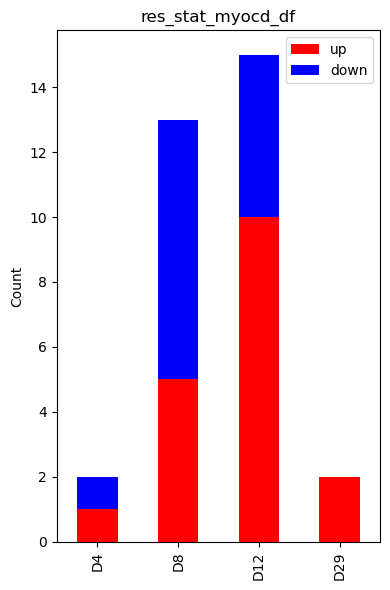

In [48]:
ax = res_stat_myocd_df.plot(
    kind="bar",
    stacked=True,
    figsize=(4, 6),              # Adjust figure size here
    color={"up": "red", "down": "blue"}  # Set colors
)

ax.set_title("res_stat_myocd_df")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="")

plt.tight_layout()
plt.savefig("./Plot/MYOCD_regulator_network_stat_time_course.pdf")  # Save as PDF
plt.show()

### Top5 Gene regulation in each program

In [43]:
def generate_graph_target(TF_regulation_df, tf_name_list, target_genes):
    # 2) Create a directed graph
    G = nx.DiGraph()

    # Add TF nodes to the graph
    G.add_nodes_from(tf_name_list,node_type="tf")
    G.add_nodes_from(target_genes, node_type="target")

    # 3) Add edges
    # Edge direction: regulating_tf -> tf_name
    for row in TF_regulation_df.itertuples():
        # Remove self-loops
        if row.gene_names == row.Pert_name:
            continue

        # Add directed edges with attributes
        # We store log2FC for weight/width and -log10(p-value) for opacity
        log_fc = np.log2(row.fc)
        
        # Calculate negative log p-value (add small epsilon to avoid log(0))
        # Using pval_empirical based on your data structure
        nlog_p = -row.Significance_score
        
        G.add_edge(row.Pert_name, row.gene_names,
                   weight=log_fc, significance=nlog_p)
    return G

In [44]:
graph_gp_top_dict = {}

print("Generating graphs...")
for target_gene in tqdm(gp_name_list):
    # Filter data (Same logic as your original code)
    gp_regulation_df_sig_target = \
        gp_regulation_df_sig[gp_regulation_df_sig["Score Column"]==target_gene].sort_values("Corrected p-value (BH)")

    gp_regulation_df_sig_target_down = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']<0]
    gp_regulation_df_sig_target_up = \
        gp_regulation_df_sig_target[gp_regulation_df_sig_target['Log2 Fold Change']>0]

    target_down_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_down["Gene"].values]
    target_up_tf_name = [x.split("-")[0] for x in gp_regulation_df_sig_target_up["Gene"].values]
    
    gp_id_str = target_gene.split("_")[1]
    top300_list = top300_gene_df[gp_id_str].values
    
    top5_list = top300_list[:5]

    DEG_tf_regulation_down = global_df[(global_df["Pert_name"].apply(lambda x: x in target_down_tf_name)) & \
                                       (global_df["gene_names"].apply(lambda x: x in top5_list))]
    DEG_tf_regulation_up   = global_df[(global_df["Pert_name"].apply(lambda x: x in target_up_tf_name)) & \
                                       (global_df["gene_names"].apply(lambda x: x in top5_list))]
    G_up = generate_graph_target(DEG_tf_regulation_up,target_up_tf_name,top5_list)
    G_down = generate_graph_target(DEG_tf_regulation_down,target_down_tf_name,top5_list)
    
    graph_gp_top_dict[f"{target_gene}_up"] = G_up
    graph_gp_top_dict[f"{target_gene}_down"] = G_down

Generating graphs...


100%|██████████| 250/250 [00:43<00:00,  5.76it/s]


In [45]:
output_filename = "./Plot/GRN_plot_target.pdf"
max_nlp = 20
with PdfPages(output_filename) as pdf:
    # The legend objects are fixed, so create them once,
    # but ax.legend() must be called inside the loop to place them on each page
    legend_handles = create_custom_legend(max_nlp)
    
    for key, G in tqdm(graph_gp_top_dict.items()):
        if G.number_of_nodes() == 0:
            continue
            
        gp_id_str = key.split("_")[1] 
    
        tf_nodes = [n for n, attr in G.nodes(data=True) if attr.get("node_type") == 'tf']
        # Layout
        pos = nx.bipartite_layout(G, nodes=tf_nodes)

        # Determine edge styles
        edge_colors = []
        edge_widths = []
        
        for u, v, data in G.edges(data=True):
            weight = data['weight']       # log2FC
            sig = data['significance']    # -log10(p-value)
            
            # Width: Global scale is implicitly consistent formula-wise
            width = 0.5 + abs(weight) * 1.5
            edge_widths.append(width)
            
            # Color base
            if weight > 0:
                base_rgb = (0, 0, 1) # Blue
            else:
                base_rgb = (1, 0, 0) # Red
            
            # Opacity: Global Normalization using global_max_nlp
            alpha = 0.2 + 0.8 * (sig / max_nlp)
            alpha = min(1.0, max(0.2, alpha))
            
            edge_colors.append(base_rgb + (alpha,))

        # Plot
        plt.figure(figsize=(20, 14)) # Widen slightly to accommodate legend
        ax = plt.gca()

        # Edges
        nx.draw_networkx_edges(
            G,
            pos,
            edge_color=edge_colors,
            width=edge_widths,
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.15",
            min_source_margin=15,
            min_target_margin=15,
        )

        # Nodes
        for node in G.nodes():
            x, y = pos[node]
            box_lw = 1.0
            font_weight = 'normal'

            ax.text(
                x, y, node,
                fontsize=9,
                fontweight=font_weight,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=dict(
                    boxstyle="round,pad=0.35",
                    fc="white",
                    ec="black",
                    lw=box_lw,
                    alpha=0.9
                ),
                zorder=10
            )

        plt.axis("off")
        plt.margins(0.1)
        
        # Title
        plt.title(f"TF-TF Regulatory Network around {key}", fontsize=16)

        # Add Legend
        # Place outside the plot (e.g., top right) using bbox_to_anchor
        lgd = ax.legend(handles=legend_handles, loc='upper left', 
                        bbox_to_anchor=(1.0, 1.0), fontsize=10, 
                        title="Legend (Unified Scale)", frameon=True)
        
        # Save PDF (use bbox_inches='tight' to prevent legend from being cut off)
        pdf.savefig(bbox_inches='tight', bbox_extra_artists=(lgd,))
        plt.close()

print(f"PDF saved to {output_filename}")

  0%|          | 0/500 [00:00<?, ?it/s]/tmp/ipykernel_1947092/3022084040.py:47: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
100%|██████████| 500/500 [00:41<00:00, 12.12it/s]

PDF saved to ./Plot/GRN_plot_target.pdf


### GO enrichment for all gene program

In [46]:
def enrichr_dotplot(
    df: pd.DataFrame,
    top_n: int = 10,
    term_col: str = "Term",
    p_col: str = "Adjusted P-value",
    odds_col: str = "Odds Ratio",
    overlap_col: str = "Overlap",
    gene_set_filter: str | None = None,
    gene_set_col: str = "Gene_set",
    figsize=(16, 4),
    size_range=(60, 420),
    dedup_term: bool = True,
    genes_legend_values=None,
    tick_labelsize_y: int = 6,
    tick_labelsize_x: int = 8,
    title_fontsize: int = 10,
    xlabel_fontsize: int = 10,
    # Layout controls: fixed widths so every figure matches
    left_pad: float = 0.02,
    right_pad: float = 0.02,
    top_pad: float = 0.88,
    bottom_pad: float = 0.18,
    # GridSpec width ratios: [main plot, colorbar, legend]
    width_ratios=(1.0, 0.035, 0.22),
):
    d = df.copy()

    # Optional filter
    if gene_set_filter is not None and gene_set_col in d.columns:
        d = d[d[gene_set_col] == gene_set_filter].copy()

    # Pick p column
    if p_col not in d.columns:
        if "P-value" in d.columns:
            p_col = "P-value"
        else:
            raise ValueError(f"p_col='{p_col}' not found and no 'P-value' column either.")

    # Genes from Overlap "15/26" -> 15
    if overlap_col not in d.columns:
        raise ValueError(f"'{overlap_col}' column not found.")
    ov = d[overlap_col].astype(str).str.split("/", expand=True)
    d["Genes"] = pd.to_numeric(ov[0], errors="coerce")

    # Numerics
    d[term_col] = d[term_col].astype(str)
    d[p_col] = pd.to_numeric(d[p_col], errors="coerce")
    d[odds_col] = pd.to_numeric(d[odds_col], errors="coerce")
    d = d.dropna(subset=[term_col, p_col, odds_col, "Genes"]).copy()

    # -log10(p)
    d["neglog10_p"] = -np.log10(np.clip(d[p_col].values, 1e-300, 1.0))

    # Deduplicate by best (smallest) p if needed
    if dedup_term:
        d = d.sort_values(p_col, ascending=True).drop_duplicates(subset=[term_col], keep="first")

    # Select and order by p (smallest first)
    d = d.sort_values(p_col, ascending=True).head(top_n).copy()

    # Preserve order for y-axis (smallest p on top)
    term_order = pd.unique(d[term_col]).tolist()
    d[term_col] = pd.Categorical(d[term_col], categories=term_order, ordered=True)

    # --- Create fixed layout: main + colorbar axis + legend axis ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 3, width_ratios=width_ratios, wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])  # colorbar axis
    lax = fig.add_subplot(gs[0, 2])  # legend axis (dedicated space)
    lax.axis("off")

    # Map Genes -> marker sizes
    gmin, gmax = d["Genes"].min(), d["Genes"].max()
    smin, smax = size_range
    if gmax == gmin:
        sizes = np.full(len(d), (smin + smax) / 2.0)
    else:
        sizes = smin + (d["Genes"] - gmin) * (smax - smin) / (gmax - gmin)

    # Scatter
    sc = ax.scatter(
        d["neglog10_p"],
        d[term_col],
        s=sizes,
        c=d[odds_col],
        cmap="Reds",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9,
    )

    # Axes styling
    ax.set_xlabel(f"-log10({p_col})", fontsize=xlabel_fontsize)
    ax.set_ylabel("")
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=tick_labelsize_y)
    ax.tick_params(axis="x", labelsize=tick_labelsize_x)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Colorbar (Odds Ratio) - fixed axis so it never overlaps or shifts
    cb = fig.colorbar(sc, cax=cax)
    cb.set_label("Odds Ratio", fontsize=9)
    cb.ax.tick_params(labelsize=8)

    # Genes legend values
    if genes_legend_values is None:
        genes_legend_values = np.unique(np.round(np.linspace(gmin, gmax, 5)).astype(int)).tolist()

    # Build size legend handles (in legend axis)
    handles, labels = [], []
    for gv in genes_legend_values:
        if gmax == gmin:
            sv = (smin + smax) / 2.0
        else:
            sv = smin + (gv - gmin) * (smax - smin) / (gmax - gmin)
        h = ax.scatter([], [], s=sv, facecolors="gray", edgecolors="black", linewidths=0.4, alpha=0.9)
        handles.append(h)
        labels.append(str(gv))

    leg = lax.legend(
        handles,
        labels,
        title="Genes",
        loc="center left",
        frameon=True,
        borderpad=0.6,
        labelspacing=0.8,
        handletextpad=0.8,
        scatterpoints=1,
    )
    leg.get_title().set_fontsize(9)
    for txt in leg.get_texts():
        txt.set_fontsize(8)

    # Manual margins (no tight_layout) -> consistent across figures
    fig.subplots_adjust(left=left_pad, right=1 - right_pad, top=top_pad, bottom=bottom_pad)

    return fig, ax

def wrap_yticklabels(ax, width=45, max_lines=3):
    # English comment: Wrap y tick labels with max lines; truncate with ellipsis
    ticks = ax.get_yticklabels()
    new_labels = []
    for t in ticks:
        wrapped = textwrap.wrap(t.get_text(), width=width)
        if len(wrapped) > max_lines:
            wrapped = wrapped[:max_lines]
            wrapped[-1] += "..."
        new_labels.append("\n".join(wrapped))
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(new_labels)

In [47]:


source_list = gp_go_df["Source"].unique()

output_filename = "./Plot/GP_GeneOntology_enrich.pdf"
with PdfPages(output_filename) as pdf:
    for source_name in tqdm(source_list):
        gp_go_df_target = gp_go_df[gp_go_df["Source"] == source_name]

        fig, ax = enrichr_dotplot(
            gp_go_df_target,
            top_n=10,
            figsize=(16, 4),
            width_ratios=(0.3, 0.015, 0.22),  # main / cbar / legend
            left_pad=0.02, right_pad=0.02, top_pad=0.88, bottom_pad=0.20,
            tick_labelsize_y=6,
        )

        # Optional: only if very long terms break layout readability
        wrap_yticklabels(ax, width=50, max_lines=3)

        ax.set_title(f"Gene Program {source_name}", fontsize=10)
        pdf.savefig(fig, bbox_inches="tight", pad_inches=0.10)
        plt.close()

print(f"PDF saved to {output_filename}")


100%|██████████| 250/250 [00:44<00:00,  5.67it/s]


PDF saved to ./Plot/GP_GeneOntology_enrich.pdf
